In [7]:
import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt
import json
import pandas as pd
from matplotlib.patches import Rectangle
from scipy.spatial.transform import Rotation as R


In [2]:
aggregated_data_path = Path('/common/users/dm1487/ktamp_data_rename/cylinder_envs_large_aggregate_temp')

data_path = aggregated_data_path # / '1_mixed'
file_list = list(data_path.glob('*/*.json'))

In [192]:
file_list

[PosixPath('/common/users/dm1487/ktamp_data_rename/cylinder_envs_large_aggregate_temp/1_movable/env_config_4520.json'),
 PosixPath('/common/users/dm1487/ktamp_data_rename/cylinder_envs_large_aggregate_temp/1_movable/env_config_4838.json'),
 PosixPath('/common/users/dm1487/ktamp_data_rename/cylinder_envs_large_aggregate_temp/1_movable/env_config_3789.json'),
 PosixPath('/common/users/dm1487/ktamp_data_rename/cylinder_envs_large_aggregate_temp/1_movable/env_config_4444.json'),
 PosixPath('/common/users/dm1487/ktamp_data_rename/cylinder_envs_large_aggregate_temp/1_movable/env_config_811.json'),
 PosixPath('/common/users/dm1487/ktamp_data_rename/cylinder_envs_large_aggregate_temp/1_movable/env_config_3425.json'),
 PosixPath('/common/users/dm1487/ktamp_data_rename/cylinder_envs_large_aggregate_temp/1_movable/env_config_1808.json'),
 PosixPath('/common/users/dm1487/ktamp_data_rename/cylinder_envs_large_aggregate_temp/1_movable/env_config_3859.json'),
 PosixPath('/common/users/dm1487/ktamp_da

In [193]:
for idx in range(30):
    with open(file_list[idx], 'r') as f:
        data = json.load(f)
        print(data['xml_path'])
        print("from file", data['reachability_radius'])
        goal_success = np.array(data['goal_success'])
        
        radius_step = 0.01
        max_radius = 1.6 + radius_step
        reachability_radius = 1.6

        for radius in np.arange(radius_step, max_radius, radius_step):
            goal_success_radius = goal_success[goal_success[:, 0]**2 + goal_success[:, 1]**2 <= radius**2]
            if len(goal_success_radius) == 0:
                continue
            if np.sum(goal_success_radius[:, 2]) / len(goal_success_radius) < 1.0:
                
                break
            reachability_radius = radius

    print("reachability radius", reachability_radius)

        # plt.scatter(goal_success_radius[:, 0], goal_success_radius[:, 1], c=goal_success_radius[:, 2], cmap='RdBu')

        # break
    
    # plt.xlim(-1.6, 1.6)
    # plt.ylim(-1.6, 1.6)
    # plt.show()


    # plt.scatter(goal_success[:, 0], goal_success[:, 1], c=goal_success[:, 2], cmap='RdBu')
    # # goal_success = np.array(data['goal_success'])[:, -1].reshape(17, 17, 1)
    # # plt.imshow(goal_success, cmap='gray')
    # plt.show()
    # plt.colorbar()

cylinder_envs/1_movable/env_config_4520.xml
from file 2.000000000000001
reachability radius 1.6
cylinder_envs/1_movable/env_config_4838.xml
from file 1.800000000000001
reachability radius 1.6
cylinder_envs/1_movable/env_config_3789.xml
from file 1.5500000000000007
reachability radius 1.59
cylinder_envs/1_movable/env_config_4444.xml
from file 2.000000000000001
reachability radius 1.6
cylinder_envs/1_movable/env_config_811.xml
from file 2.000000000000001
reachability radius 1.6
cylinder_envs/1_movable/env_config_3425.xml
from file 2.000000000000001
reachability radius 1.6
cylinder_envs/1_movable/env_config_1808.xml
from file 2.000000000000001
reachability radius 1.6
cylinder_envs/1_movable/env_config_3859.xml
from file 1.4500000000000006
reachability radius 1.46
cylinder_envs/1_movable/env_config_1474.xml
from file 2.000000000000001
reachability radius 1.6
cylinder_envs/1_movable/env_config_3541.xml
from file 2.000000000000001
reachability radius 1.6
cylinder_envs/1_movable/env_config_97

In [194]:
aggregated_data_path = Path('/common/users/dm1487/ktamp_data_rename/cylinder_envs_large_aggregate_new_temp_1')
data_path = aggregated_data_path # / '1_mixed'
file_list = list(data_path.glob('*/*.json'))

In [195]:
with open(file_list[0], 'r') as f:
    data = json.load(f)

(40, 40)
(40, 40)
(40, 40)
(40, 40)


Text(0.5, 1.0, 'Robot Mask')

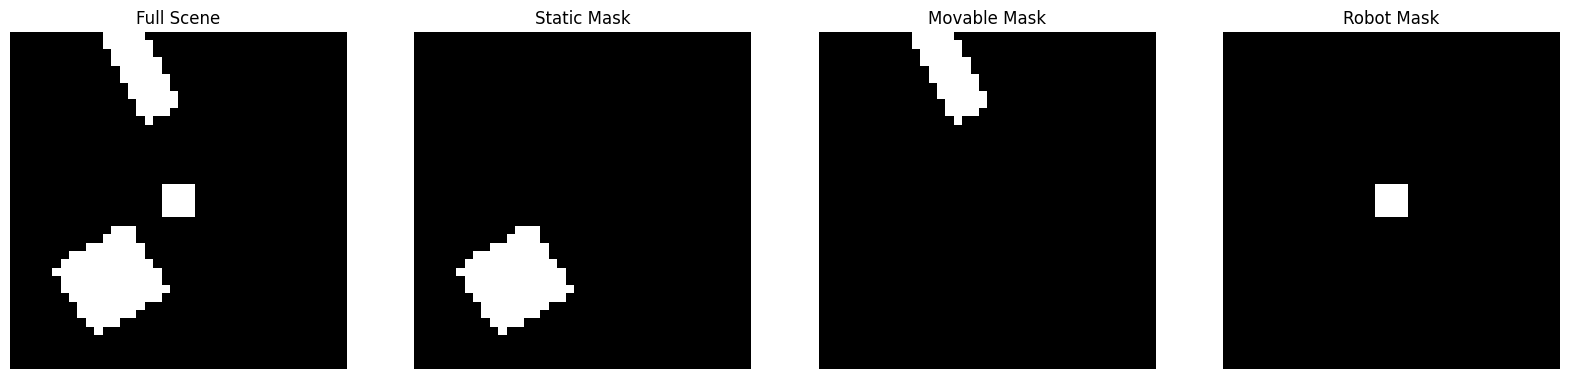

In [196]:
full_scene = np.array(data['scene_images']['full_scene'])
static_mask = np.array(data['scene_images']['static_mask'])
movable_mask = np.array(data['scene_images']['movable_mask'])
robot_mask = np.array(data['scene_images']['robot_mask'])

print(full_scene.shape)
print(static_mask.shape)
print(movable_mask.shape)
print(robot_mask.shape)

fig, axs = plt.subplots(1, 4, figsize=(20, 5))
axs[0].imshow(full_scene, cmap='gray')
axs[0].axis('off')
axs[0].set_title('Full Scene')

axs[1].imshow(static_mask, cmap='gray')
axs[1].axis('off')
axs[1].set_title('Static Mask')

axs[2].imshow(movable_mask, cmap='gray')
axs[2].axis('off')
axs[2].set_title('Movable Mask')

axs[3].imshow(robot_mask, cmap='gray')
axs[3].axis('off')
axs[3].set_title('Robot Mask')

In [197]:
folder = Path("namo_trajectories")
file_list = list(folder.glob('*.txt'))
lines = []
for i in file_list:
    with open(i, 'r') as f:
        data = f.readlines()
    for line in data:
        line = np.array(line.strip().split()).astype(float)
        lines.append(line)
lines = np.array(lines)

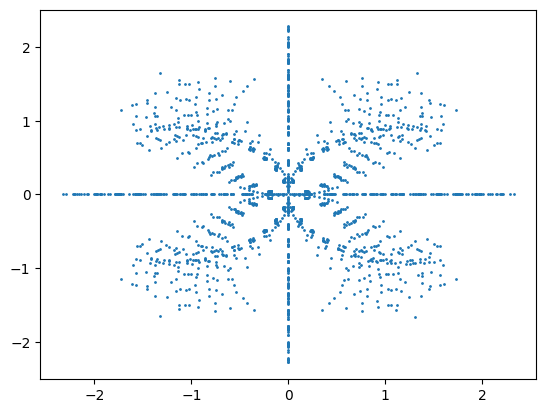

In [198]:
plt.scatter(lines[:, 0], lines[:, 1], s=1)

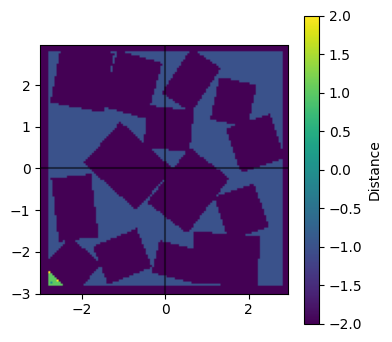

In [13]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle

def plot_wavefront(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            data.append([float(x) for x in line.strip().split()])
      
    data = np.array(data)
    grid_size = len(np.unique(data[:, 0]))
    grid = data[:, -1].reshape(grid_size, grid_size)


    x_lims = [np.min(np.unique(data[:, 0])), np.max(np.unique(data[:, 0]))]
    y_lims = [np.min(np.unique(data[:, 1])), np.max(np.unique(data[:, 1]))]

    # Create a figure with a larger size
    plt.figure(figsize=(4, 4))

    # Plot with origin at center and correct orientation
    plt.imshow(grid.T, origin='lower', extent=[x_lims[0], x_lims[1], y_lims[0], y_lims[1]])

    # Add grid lines
    # plt.grid(True, linestyle='--', alpha=0.7)

    # Add axes lines for x=0 and y=0
    plt.axhline(y=0, color='k', linestyle='-', alpha=0.5)
    plt.axvline(x=0, color='k', linestyle='-', alpha=0.5)

    # plt.xlabel('X Position')
    # plt.ylabel('Y Position')
    # plt.title('Wavefront Distance Map')

    # Add colorbar with label
    plt.colorbar(label='Distance')

plot_wavefront("wavefronts/4/wavefront_data_1.txt")

In [5]:
def animate_wavefronts(folder_path, interval=200, save_path=None):
    """
    Create an animation of wavefront data from multiple files.
    
    Parameters:
    -----------
    folder_path : str
        Path to the folder containing wavefront data files
    interval : int
        Milliseconds between frames
    save_path : str or None
        Path to save animation (None = display only)
    """
    from matplotlib import pyplot as plt
    from matplotlib import animation
    import glob
    import os
    import re
    
    # Get all text files in the folder
    file_pattern = os.path.join(folder_path, "wavefront_data_*.txt")
    file_list = sorted(glob.glob(file_pattern), 
                      key=lambda x: int(re.findall(r'_(\d+)\.txt$', x)[0]))
    
    if not file_list:
        print(f"No files found matching pattern {file_pattern}")
        return None
    
    print(f"Found {len(file_list)} files to animate")
    
    # Read first file to determine dimensions and data range
    data = []
    with open(file_list[0], "r") as f:
        for line in f:
            data.append([float(x) for x in line.strip().split()])
    
    data = np.array(data)
    grid_size = len(np.unique(data[:, 0]))
    grid = data[:, -1].reshape(grid_size, grid_size)
    
    # Find global min/max for consistent colormap
    vmin, vmax = np.min(grid), np.max(grid)
    for file in file_list[1:]:
        try:
            data = np.loadtxt(file)
            grid = data[:, -1].reshape(grid_size, grid_size)
            vmin = min(vmin, np.min(grid))
            vmax = max(vmax, np.max(grid))
        except Exception as e:
            print(f"Warning: Error reading {file}: {e}")
    
    # Setup figure
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # First plot with actual data
    x_lims = [np.min(np.unique(data[:, 0])), np.max(np.unique(data[:, 0]))]
    y_lims = [np.min(np.unique(data[:, 1])), np.max(np.unique(data[:, 1]))]
    
    im = ax.imshow(grid.T, origin='lower', cmap='viridis', 
                   vmin=vmin, vmax=vmax,
                   extent=[x_lims[0], x_lims[1], y_lims[0], y_lims[1]], 
                   animated=True)
    
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.5)
    ax.axvline(x=0, color='k', linestyle='-', alpha=0.5)
    
    # Add colorbar
    # cbar = fig.colorbar(im, ax=ax)
    # cbar.set_label('Value')
    
    # Add text for frame counter
    frame_text = ax.text(0.02, 0.98, '', transform=ax.transAxes, 
                         verticalalignment='top', fontsize=10)
    
    def update(frame):
        try:
            # Load data from the current file
            data = []
            with open(file_list[frame], "r") as f:
                for line in f:
                    data.append([float(x) for x in line.strip().split()])
            
            data = np.array(data)
            grid = data[:, -1].reshape(grid_size, grid_size)
            
            # Update plot
            im.set_array(grid.T)
            frame_text.set_text(f'Frame: {frame+1}/{len(file_list)}')
            
            return [im, frame_text]
        except Exception as e:
            print(f"Error in frame {frame}: {e}")
            return [im, frame_text]
    
    ani = animation.FuncAnimation(
        fig, 
        update, 
        frames=range(len(file_list), 100),
        interval=interval, 
        blit=True
    )
    
    if save_path:
        try:
            ani.save(save_path, writer='ffmpeg')
            print(f"Animation saved to {save_path}")
        except Exception as e:
            print(f"Error saving animation: {e}")
    else:
        plt.tight_layout()
        plt.show()
    
    return ani

# Example usage: animate the wavefront files
animate_wavefronts("wavefronts/1", interval=500, save_path="wavefront_animation.mp4")

Found 5 files to animate


NameError: name 'np' is not defined

IndexError: single positional indexer is out-of-bounds

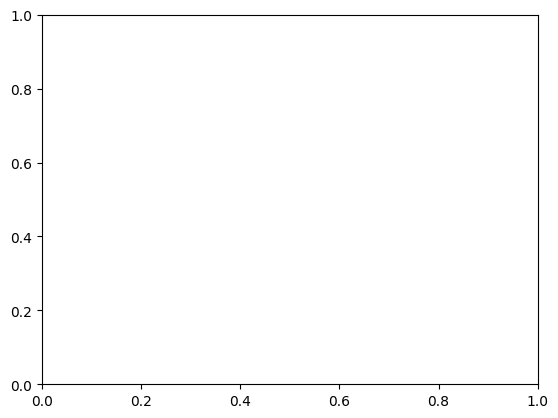

In [201]:
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle
from scipy.spatial.transform import Rotation as R

df = pd.read_csv("namo_objects.txt", sep=",")

data_df = pd.read_csv("namo_state_log.csv")

def create_rectangle(pos, quat, size):
    # Convert quaternion to rotation matrix
    rot = R.from_quat(quat, scalar_first=True).as_euler('xyz', degrees=True)
    if rot[-1] < 0:
        rot[-1] += 360
    # Create a rectangle patch
    rect = Rectangle((pos[0] - size[0], pos[1] - size[1]), size[0]*2, size[1]*2, angle=rot[-1], rotation_point='center', fill=True, color='red', alpha=0.5)
    return rect

fig = plt.figure()
ax = fig.add_subplot(111)
# pos = data_df[['robot_x', 'robot_y']].iloc[0].values
# size = df.loc[df['object_name'] == 'robot', ['size_x', 'size_x']].values[0]
# pch = create_rectangle(pos, quat=[1, 0, 0, 0], size=size)
# ax.add_patch(pch)

i = 9000
for name in df['object_name'].unique():
    if "movable" in name or "robot" in name:
        pos = data_df[[f'{name}_x', f'{name}_y']].iloc[i].values
        if name == "robot":
            quat = [1, 0, 0, 0]
            size = [0.1, 0.1]
        else:
            quat = data_df[[f'{name}_qw', f'{name}_qx', f'{name}_qy', f'{name}_qz']].iloc[i].values
            size = df.loc[df['object_name'] == name, ['size_x', 'size_y']].values[0]
        pch = create_rectangle(pos, quat, size)
        ax.add_patch(pch)

ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
plt.show()

In [153]:
def animate_namo_simulation(data_df, df, start_frame=0, end_frame=None, interval=100, save_path=None):
    """
    Create an animation of the NAMO environment simulation.

    Parameters:
    -----------
    data_df : pandas DataFrame
        DataFrame containing state log data
    df : pandas DataFrame
        DataFrame containing object information
    start_frame : int
        First frame to show
    end_frame : int or None
        Last frame to show (None = use all frames)
    interval : int
        Milliseconds between frames
    save_path : str or None
        Path to save animation (None = display only)
    """
    from matplotlib import pyplot as plt
    from matplotlib.patches import Rectangle
    from matplotlib import animation
    from scipy.spatial.transform import Rotation as R

    if end_frame is None:
        end_frame = len(data_df)

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111)
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_title('NAMO Environment Simulation')

    circle = plt.Circle((2.5, 2.5), 0.3, fill=True, color='green', alpha=0.5)
    ax.add_patch(circle)
    # Create a dictionary to store patch objects for each object
    patches = {}
    for name in df['object_name'].unique():
        if "movable" in name or "robot" in name:
            # Initialize with placeholder - will be updated in animation
            patches[name] = Rectangle((-100, -100), 0.1, 0.1, fill=True, alpha=0.5, rotation_point='center')
            ax.add_patch(patches[name])

    # Text for frame counter
    frame_text = ax.text(0.02, 0.98, '', transform=ax.transAxes, 
                            verticalalignment='top', fontsize=10)

    def init():
        # Initialize all patches as invisible
        for patch in patches.values():
            patch.set_visible(False)
        frame_text.set_text('')
        return list(patches.values()) + [frame_text]

    def update(frame):
        frame_text.set_text(f'Frame: {frame}/{end_frame-1}')
        for name in df['object_name'].unique():
            if "movable" in name or "robot" in name:
                # Make sure the frame exists in the data
                if frame < len(data_df):
                    pos = data_df[[f'{name}_x', f'{name}_y']].iloc[frame].values
                    if name == "robot":
                        quat = [1, 0, 0, 0]
                        size = [0.1, 0.1]
                        color = 'red'
                    else:
                        quat = data_df[[f'{name}_qw', f'{name}_qx', f'{name}_qy', f'{name}_qz']].iloc[frame].values
                        size = df.loc[df['object_name'] == name, ['size_x', 'size_y']].values[0]
                        color = 'dodgerblue'
                    
                    # Convert quaternion to rotation angle
                    rot = R.from_quat(quat, scalar_first=True).as_euler('xyz', degrees=True)
                    if rot[-1] < 0:
                        rot[-1] += 360
                    # Update patch properties
                    patch = patches[name]
                    patch.set_xy((pos[0] - size[0], pos[1] - size[1]))
                    patch.set_width(size[0]*2)
                    patch.set_height(size[1]*2)
                    patch.set_angle(rot[-1])
                    patch.set_color(color)
                    patch.set_visible(True)
        
        return list(patches.values()) + [frame_text]

    ani = animation.FuncAnimation(
        fig, 
        update, 
        frames=range(start_frame, end_frame, 50),
        init_func=init,
        interval=interval, 
        blit=True
    )

    if save_path:
        ani.save(save_path, writer='ffmpeg')
        print(f"Animation saved to {save_path}")
    else:
        plt.show()

    return ani

Animation saved to namo_animation_3.mp4


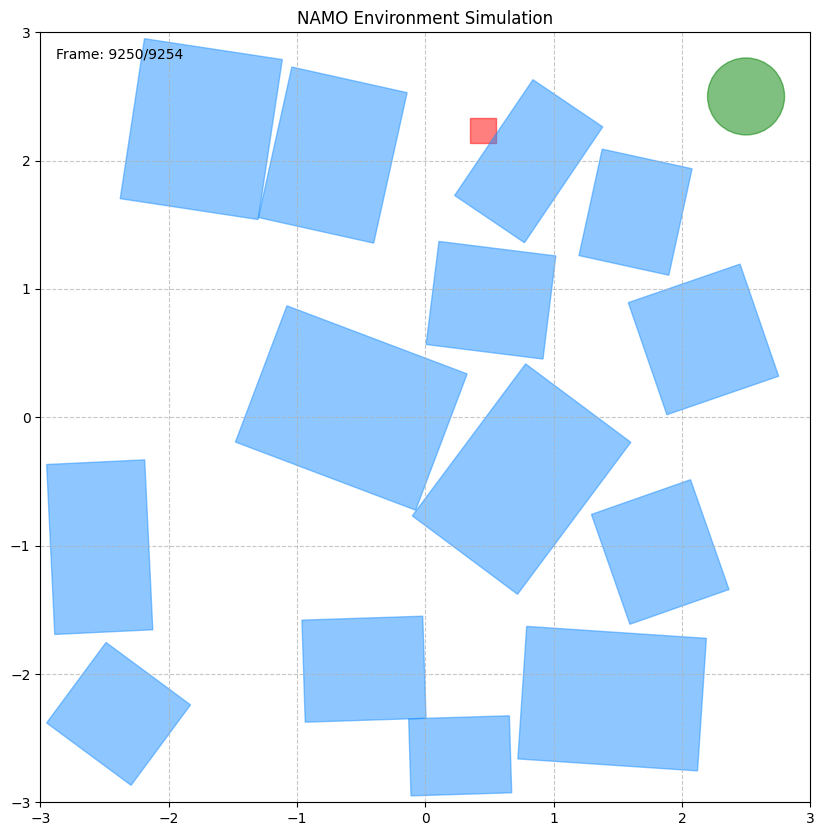

In [156]:
# animate_namo_simulation(data_df, df, start_frame=0, end_frame=200, interval=50)

df = pd.read_csv("namo_objects.txt", sep=",")

data_df = pd.read_csv("namo_state_log.csv")

animate_namo_simulation(data_df, df, start_frame=0, end_frame=data_df.shape[0], interval=100, save_path="namo_animation_3.mp4")

In [2]:
def animate_namo_with_wavefront(data_df, df, wavefront_folder, start_frame=0, end_frame=None, interval=100, save_path=None):
    """
    Create a combined animation of the NAMO environment simulation with wavefront visualization.

    Parameters:
    -----------
    data_df : pandas DataFrame
        DataFrame containing state log data
    df : pandas DataFrame
        DataFrame containing object information
    wavefront_folder : str
        Path to folder containing wavefront data files (e.g., "wavefronts/195")
    start_frame : int
        First frame to show
    end_frame : int or None
        Last frame to show (None = use all frames)
    interval : int
        Milliseconds between frames
    save_path : str or None
        Path to save animation (None = display only)
    """
    from matplotlib import pyplot as plt
    from matplotlib.patches import Rectangle, Circle
    from matplotlib import animation
    from scipy.spatial.transform import Rotation as R
    import numpy as np
    import os
    import re
    import glob
    from tqdm import tqdm

    if end_frame is None:
        end_frame = len(data_df)

    # Set up figure with two subplots side by side
    fig = plt.figure(figsize=(15, 7))
    ax1 = fig.add_subplot(121)  # For wavefront
    ax2 = fig.add_subplot(122)  # For NAMO objects
    
    # Configure NAMO objects subplot
    ax2.set_xlim(-3, 3)
    ax2.set_ylim(-3, 3)
    ax2.set_aspect('equal')
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.set_title('NAMO Environment Simulation')
    
    # Goal indicator
    goal_circle = Circle((2.5, 2.5), 0.3, fill=True, color='green', alpha=0.5)
    ax2.add_patch(goal_circle)
    
    # Create patches for each object
    patches = {}
    for name in df['object_name'].unique():
        if "movable" in name or "robot" in name:
            patches[name] = Rectangle((-100, -100), 0.1, 0.1, fill=True, alpha=0.5, rotation_point='center')
            ax2.add_patch(patches[name])

    # Get all wavefront files in the folder
    file_pattern = os.path.join(wavefront_folder, "wavefront_data_*.txt")
    wavefront_files = sorted(glob.glob(file_pattern), 
                      key=lambda x: int(re.findall(r'_(\d+)\.txt$', x)[0]))
    
    if not wavefront_files:
        print(f"No wavefront files found in {wavefront_folder}")
        return None
    
    print(f"Found {len(wavefront_files)} wavefront files")
    
    # Read first wavefront file to determine dimensions and setup
    first_data = []
    with open(wavefront_files[0], "r") as f:
        for line in f:
            first_data.append([float(x) for x in line.strip().split()])
    
    first_data = np.array(first_data)
    grid_size = len(np.unique(first_data[:, 0]))
    grid = first_data[:, -1].reshape(grid_size, grid_size)
    
    # Find global min/max for consistent colormap
    vmin, vmax = -2, 10
    
    # Setup wavefront subplot
    x_lims = [np.min(np.unique(first_data[:, 0])), np.max(np.unique(first_data[:, 0]))]
    y_lims = [np.min(np.unique(first_data[:, 1])), np.max(np.unique(first_data[:, 1]))]
    
    wavefront_im = ax1.imshow(grid.T, origin='lower', cmap='viridis', 
                  vmin=vmin, vmax=vmax,
                  extent=[x_lims[0], x_lims[1], y_lims[0], y_lims[1]])
    
    ax1.axhline(y=0, color='k', linestyle='-', alpha=0.5)
    ax1.axvline(x=0, color='k', linestyle='-', alpha=0.5)
    ax1.set_title('Wavefront Distance Map')
    ax1.set_aspect('equal')
    
    # Add colorbar
    cbar = fig.colorbar(wavefront_im, ax=ax1)
    cbar.set_label('Distance')
    
    # Text for frame counter
    frame_text = fig.text(0.02, 0.98, '', transform=fig.transFigure, 
                         verticalalignment='top', fontsize=10)
    
    # Create a mapping from wavefront_id to wavefront file
    wavefront_id_to_file = {}
    for file in wavefront_files:
        file_id = int(re.findall(r'_(\d+)\.txt$', file)[0])
        wavefront_id_to_file[file_id] = file

    pbar = tqdm(range(start_frame, end_frame, 20))
    
    def init():
        # Initialize all patches as invisible
        for patch in patches.values():
            patch.set_visible(False)
        frame_text.set_text('')
        return [wavefront_im, frame_text] + list(patches.values())

    def update(frame_idx):
        # Get actual frame number from range
        frame = start_frame + frame_idx

        pbar.update(1)
        
        if frame >= len(data_df):
            return [wavefront_im, frame_text] + list(patches.values())
        
        frame_text.set_text(f'Frame: {frame}/{end_frame-1}')
        
        # Update NAMO objects
        for name in df['object_name'].unique():
            if "movable" in name or "robot" in name:
                pos = data_df[[f'{name}_x', f'{name}_y']].iloc[frame].values
                if name == "robot":
                    quat = [1, 0, 0, 0]
                    size = [0.1, 0.1]
                    color = 'red'
                else:
                    quat = data_df[[f'{name}_qw', f'{name}_qx', f'{name}_qy', f'{name}_qz']].iloc[frame].values
                    size = df.loc[df['object_name'] == name, ['size_x', 'size_y']].values[0]
                    color = 'dodgerblue'
                
                # Convert quaternion to rotation angle
                rot = R.from_quat(quat, scalar_first=True).as_euler('xyz', degrees=True)
                if rot[-1] < 0:
                    rot[-1] += 360
                
                # Update patch properties
                patch = patches[name]
                patch.set_xy((pos[0] - size[0], pos[1] - size[1]))
                patch.set_width(size[0]*2)
                patch.set_height(size[1]*2)
                patch.set_angle(rot[-1])
                patch.set_color(color)
                patch.set_visible(True)
        
        # Get wavefront_id for this frame
        if 'wavefront_id' in data_df.columns:
            wavefront_id = data_df['wavefront_id'].iloc[frame]
            
            # Load and display corresponding wavefront file if it exists
            if wavefront_id in wavefront_id_to_file:
                wavefront_file = wavefront_id_to_file[wavefront_id]
                try:
                    wf_data = []
                    with open(wavefront_file, "r") as f:
                        for line in f:
                            wf_data.append([float(x) for x in line.strip().split()])
                    
                    wf_data = np.array(wf_data)
                    wf_grid = wf_data[:, -1].reshape(grid_size, grid_size)
                    wavefront_im.set_array(wf_grid.T)
                except Exception as e:
                    print(f"Error loading wavefront file {wavefront_file}: {e}")
        
        return [wavefront_im, frame_text] + list(patches.values())

    ani = animation.FuncAnimation(
        fig, 
        update, 
        frames=range(start_frame, end_frame, 20),
        init_func=init,
        interval=interval, 
        blit=True
    )

    if save_path:
        ani.save(save_path, writer='ffmpeg')
        print(f"Animation saved to {save_path}")
    else:
        plt.tight_layout()
        plt.show()

    pbar.close()

    return ani


In [3]:
# Load the data
df = pd.read_csv("namo_objects.txt", sep=",")
data_df = pd.read_csv("namo_state_log.csv")

# Create the combined animation
animate_namo_with_wavefront(
    data_df, 
    df, 
    "wavefronts/39", 
    start_frame=0, 
    end_frame=data_df.shape[0], 
    interval=50, 
    save_path="namo_wavefront_combined.mp4"
)


NameError: name 'pd' is not defined

In [21]:
def animate_namo_with_wavefront_merged(data_df, df, wavefront_folder, start_frame=0, end_frame=None, interval=100, save_path=None):
    """
    Create a merged animation showing both wavefront and objects on a single plot.

    Parameters:
    -----------
    data_df : pandas DataFrame
        DataFrame containing state log data
    df : pandas DataFrame
        DataFrame containing object information
    wavefront_folder : str
        Path to folder containing wavefront data files (e.g., "wavefronts/195")
    start_frame : int
        First frame to show
    end_frame : int or None
        Last frame to show (None = use all frames)
    interval : int
        Milliseconds between frames
    save_path : str or None
        Path to save animation (None = display only)
    """
    from matplotlib import pyplot as plt
    from matplotlib.patches import Rectangle, Circle
    from matplotlib import animation
    from scipy.spatial.transform import Rotation as R
    import numpy as np
    import os
    import re
    import glob
    from tqdm import tqdm
    
    if end_frame is None:
        end_frame = len(data_df)

    # Set up figure with a single plot
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Configure plot settings
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_title('NAMO Environment with Wavefront Reachability Map')
    
    # Goal indicator
    goal_circle = Circle((2.5, 2.5), 0.3, fill=True, color='green', alpha=0.5)
    ax.add_patch(goal_circle)
    
    # Get all wavefront files in the folder
    file_pattern = os.path.join(wavefront_folder, "wavefront_data_*.txt")
    wavefront_files = sorted(glob.glob(file_pattern), 
                     key=lambda x: int(re.findall(r'_(\d+)\.txt$', x)[0]))
    
    if not wavefront_files:
        print(f"No wavefront files found in {wavefront_folder}")
        return None
    
    print(f"Found {len(wavefront_files)} wavefront files")
    
    # Read first wavefront file to determine dimensions and setup
    first_data = []
    with open(wavefront_files[0], "r") as f:
        for line in f:
            first_data.append([float(x) for x in line.strip().split()])
    
    first_data = np.array(first_data)
    grid_size = len(np.unique(first_data[:, 0]))
    grid = first_data[:, -1].reshape(grid_size, grid_size)
    
    # Find global min/max for consistent colormap
    vmin, vmax = -2, 10
    
    # Setup wavefront background (initialize with first file)
    x_lims = [np.min(np.unique(first_data[:, 0])), np.max(np.unique(first_data[:, 0]))]
    y_lims = [np.min(np.unique(first_data[:, 1])), np.max(np.unique(first_data[:, 1]))]
    
    wavefront_im = ax.imshow(grid.T, origin='lower', cmap='twilight_shifted', 
                  vmin=vmin, vmax=vmax, alpha=0.7,
                  extent=[x_lims[0], x_lims[1], y_lims[0], y_lims[1]])
    
    # Add coordinate axes for reference
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.5)
    ax.axvline(x=0, color='k', linestyle='-', alpha=0.5)
    
    # Add colorbar
    # cbar = fig.colorbar(wavefront_im, ax=ax)
    # cbar.set_label('Distance')
    
    # Create patches for each object
    patches = {}
    for name in df['object_name'].unique():
        if "movable" in name or "robot" in name:
            patches[name] = Rectangle((-100, -100), 0.1, 0.1, fill=True, alpha=0.7, 
                                     rotation_point='center', edgecolor='black', linewidth=1)
            ax.add_patch(patches[name])
    
    # Text for frame counter
    frame_text = ax.text(0.02, 0.98, '', transform=ax.transAxes, 
                        verticalalignment='top', fontsize=10, 
                        bbox=dict(facecolor='white', alpha=0.7))
    
    # Create a mapping from wavefront_id to wavefront file
    wavefront_id_to_file = {}
    for file in wavefront_files:
        file_id = int(re.findall(r'_(\d+)\.txt$', file)[0])
        wavefront_id_to_file[file_id] = file
    
    pbar = tqdm(range(start_frame, end_frame, 20))

    def init():
        # Initialize all patches as invisible
        for patch in patches.values():
            patch.set_visible(False)
        frame_text.set_text('')
        return [wavefront_im, frame_text] + list(patches.values())

    def update(frame_idx):
        # Get actual frame number from range
        frame = start_frame + frame_idx
        pbar.update(1)
        if frame >= len(data_df):
            return [wavefront_im, frame_text] + list(patches.values())
        
        frame_text.set_text(f'Frame: {frame}/{end_frame-1}')
        
        # Update wavefront visualization first (as background)
        if 'wavefront_id' in data_df.columns:
            wavefront_id = data_df['wavefront_id'].iloc[frame]
            
            # Load and display corresponding wavefront file if it exists
            if wavefront_id in wavefront_id_to_file:
                wavefront_file = wavefront_id_to_file[wavefront_id]
                try:
                    wf_data = []
                    with open(wavefront_file, "r") as f:
                        for line in f:
                            wf_data.append([float(x) for x in line.strip().split()])
                    
                    wf_data = np.array(wf_data)
                    wf_grid = wf_data[:, -1].reshape(grid_size, grid_size)
                    wavefront_im.set_array(wf_grid.T)
                except Exception as e:
                    print(f"Error loading wavefront file {wavefront_file}: {e}")
        
        # Update NAMO objects on top of wavefront
        for name in df['object_name'].unique():
            if "movable" in name or "robot" in name:
                pos = data_df[[f'{name}_x', f'{name}_y']].iloc[frame].values
                if name == "robot":
                    quat = [1, 0, 0, 0]
                    size = [0.1, 0.1]
                    color = 'black'
                else:
                    quat = data_df[[f'{name}_qw', f'{name}_qx', f'{name}_qy', f'{name}_qz']].iloc[frame].values
                    size = df.loc[df['object_name'] == name, ['size_x', 'size_y']].values[0]
                    color = 'yellow'
                
                # Convert quaternion to rotation angle
                rot = R.from_quat(quat, scalar_first=True).as_euler('xyz', degrees=True)
                if rot[-1] < 0:
                    rot[-1] += 360
                
                # Update patch properties
                patch = patches[name]
                patch.set_xy((pos[0] - size[0], pos[1] - size[1]))
                patch.set_width(size[0]*2)
                patch.set_height(size[1]*2)
                patch.set_angle(rot[-1])
                patch.set_color(color)
                patch.set_visible(True)
        
        return [wavefront_im, frame_text] + list(patches.values())

    ani = animation.FuncAnimation(
        fig, 
        update, 
        frames=range(start_frame, end_frame, 20),
        init_func=init,
        interval=interval, 
        blit=True
    )

    if save_path:
        ani.save(save_path, writer='ffmpeg')
        print(f"Animation saved to {save_path}")
    else:
        plt.tight_layout()
        plt.show()

    return ani

Found 14 wavefront files


Animation saved to namo_wavefront_merged_15.mp4


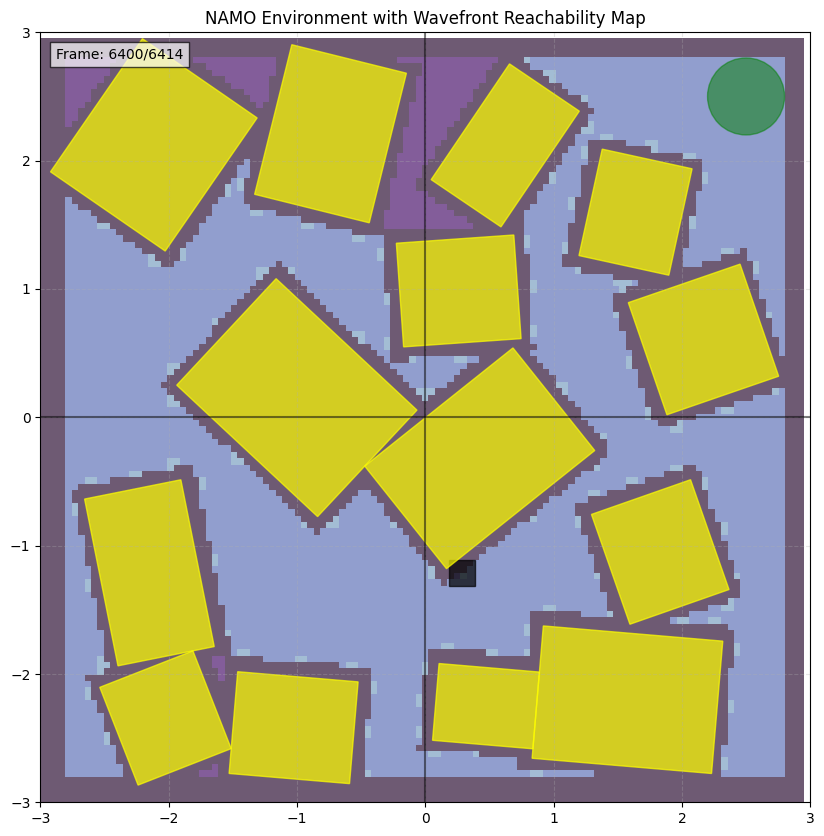

In [34]:

# Load the data
import pandas as pd
df = pd.read_csv("namo_objects.txt", sep=",")
data_df = pd.read_csv("namo_state_log_1.csv")

# Create the combined animation
animate_namo_with_wavefront_merged(
    data_df, 
    df, 
    "wavefronts/22", 
    start_frame=0, 
    end_frame=data_df.shape[0], 
    interval=50, 
    save_path="namo_wavefront_merged_15.mp4"
)

Found 3 wavefront files
Animation saved to namo_wavefront_merged_15_clean_2.mp4


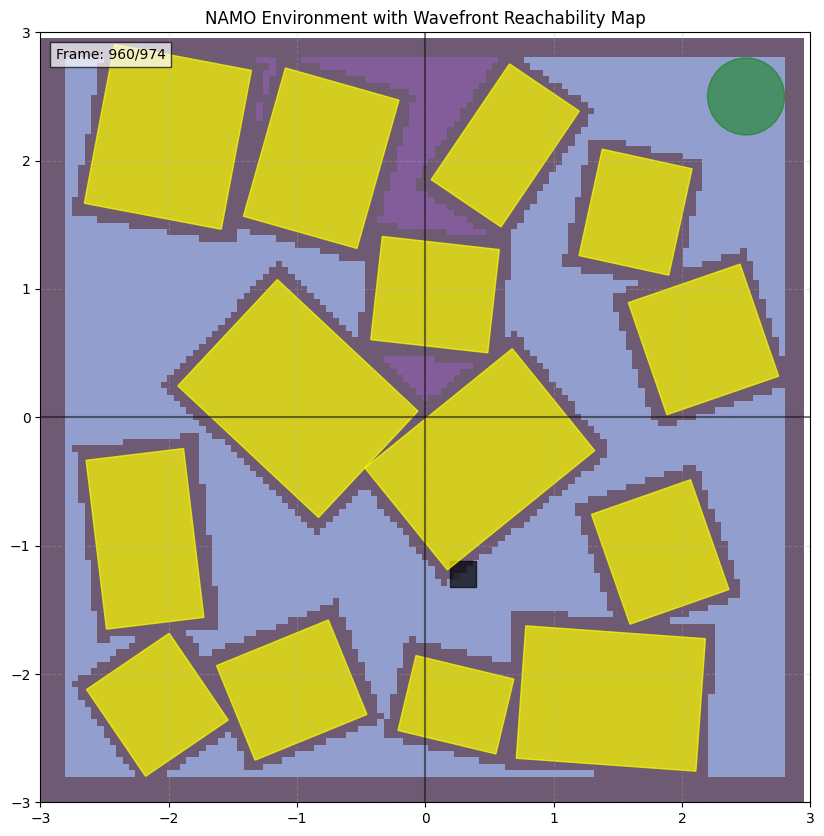

In [36]:

# Load the data
import pandas as pd
df = pd.read_csv("namo_objects.txt", sep=",")
data_df = pd.read_csv("namo_state_log_3.csv")

# Create the combined animation
animate_namo_with_wavefront_merged(
    data_df, 
    df, 
    "sol_wavefronts/7", 
    start_frame=0, 
    end_frame=data_df.shape[0], 
    interval=50, 
    save_path="namo_wavefront_merged_15_clean_2.mp4"
)

In [48]:
grid_size

160

In [22]:
np.unique(data[:, 0])

array([-2.525, -2.475, -2.425, -2.375, -2.325, -2.275, -2.225, -2.175,
       -2.125, -2.075, -2.025, -1.975, -1.925, -1.875, -1.825, -1.775,
       -1.725, -1.675, -1.625, -1.575, -1.525, -1.475, -1.425, -1.375,
       -1.325, -1.275, -1.225, -1.175, -1.125, -1.075, -1.025, -0.975,
       -0.925, -0.875, -0.825, -0.775, -0.725, -0.675, -0.625, -0.575,
       -0.525, -0.475, -0.425, -0.375, -0.325, -0.275, -0.225, -0.175,
       -0.125, -0.075, -0.025,  0.025,  0.075,  0.125,  0.175,  0.225,
        0.275,  0.325,  0.375,  0.425,  0.475,  0.525,  0.575,  0.625,
        0.675,  0.725,  0.775,  0.825,  0.875,  0.925,  0.975,  1.025,
        1.075,  1.125,  1.175,  1.225,  1.275,  1.325,  1.375,  1.425,
        1.475,  1.525,  1.575,  1.625,  1.675,  1.725,  1.775,  1.825,
        1.875,  1.925,  1.975,  2.025,  2.075,  2.125,  2.175,  2.225,
        2.275,  2.325,  2.375,  2.425])

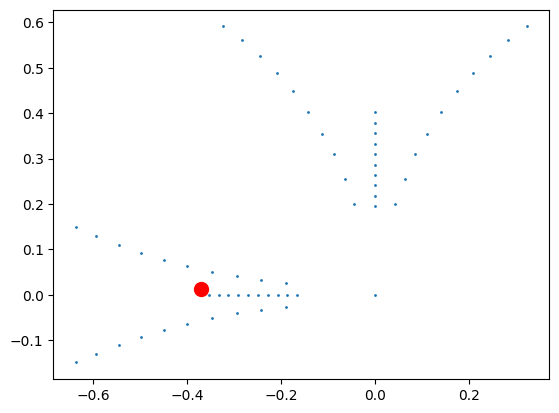

In [4]:
file = "search_states/search_states_final.txt"
lines = []
with open(file, 'r') as f:
        all_data = f.readlines()
        goal_line = all_data[0]
        goal_line = goal_line.split(" # goal:")[-1].strip().split()
        goal_line = np.array(goal_line).astype(float)
        data = all_data[1:]


for line in data:
    line = np.array(line.strip().split()).astype(float)
    lines.append(line)
lines = np.array(lines)
plt.scatter(lines[:, 0], lines[:, 1], s=1)
plt.scatter(goal_line[0], goal_line[1], s=100, c='red')

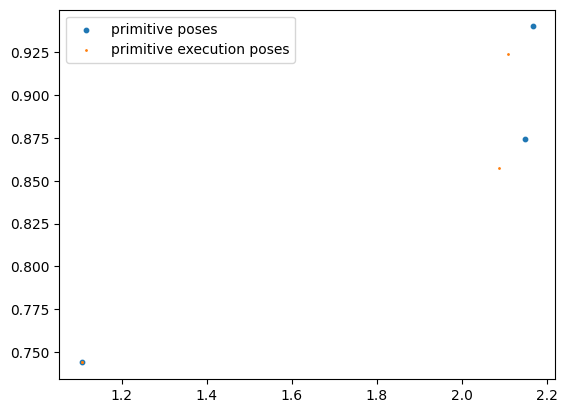

In [5]:
file_1 = "primitive_poses.txt"
file_2 = "primitive_execution_states.txt"
lines_1 = []
lines_2 = []
with open(file_1, 'r') as f:
        all_data = f.readlines()
        data = all_data

for line in data:
    line = np.array(line.strip().split()).astype(float)
    lines_1.append(line)
lines_1 = np.array(lines_1)
plt.scatter(lines_1[:, 0], lines_1[:, 1], s=10, label="primitive poses")

with open(file_2, 'r') as f:
    all_data = f.readlines()
    data = all_data

for line in data:
    line = np.array(line.strip().split()).astype(float)
    lines_2.append(line)
lines_2 = np.array(lines_2)
plt.scatter(lines_2[:, 0], lines_2[:, 1], s=1, label="primitive execution poses")
plt.legend()

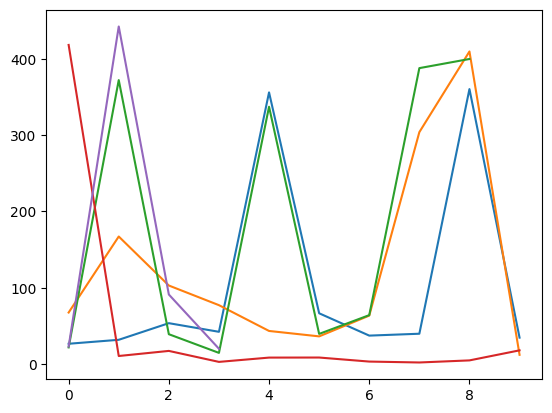

In [239]:
with open("timing_stats.txt", "r") as f:
    data = f.readlines()

d = {}
for i in data:
    i = i.strip().split()
    if float(i[-1]) > 0:
        if i[0] not in d:
            d[i[0]] = []
        d[i[0]].append(float(i[-1]))

for i in d.keys():
    plt.plot(d[i], label=i)
